Simulation_EdgeDislocation_1v: Ea=0.6482 eV, D0=4.70e-08 m^2/s, R2=0.961
Simulation_EdgeDislocation_1vv: Ea=0.7640 eV, D0=4.79e-09 m^2/s, R2=0.971
Simulation_ScrewDislocation_1v: Ea=0.7036 eV, D0=3.31e-09 m^2/s, R2=0.901
Simulation_ScrewDislocation_1vv: Ea=0.9129 eV, D0=2.43e-10 m^2/s, R2=0.936


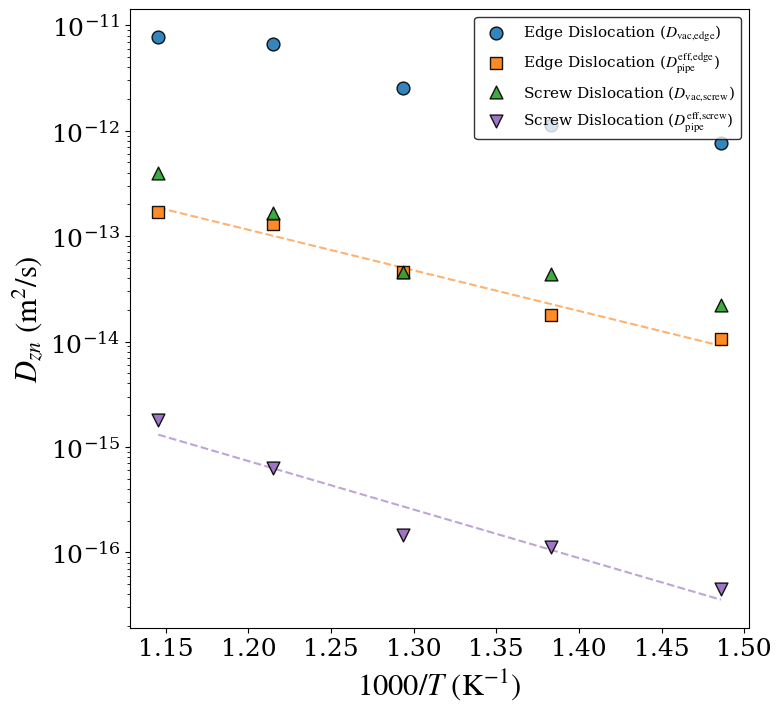

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as ticker

# 1. Configuration
excel_file = 'Arrhenius_to_plot.xlsx'

# Updated Sheets list
sheets = [
    "Simulation_EdgeDislocation_1v", 
    "Simulation_EdgeDislocation_1vv",
    "Simulation_ScrewDislocation_1v", 
    "Simulation_ScrewDislocation_1vv"
]

# --- MANUALLY CHANGE LEGEND NAMES HERE ---
legend_mapping = {
    "Simulation_EdgeDislocation_1v": r"Edge Dislocation ($D_{\text{vac,edge}}$)",
    "Simulation_EdgeDislocation_1vv": r"Edge Dislocation ($D_{\text{pipe}}^{\text{eff,edge}}$)",
    "Simulation_ScrewDislocation_1v": r"Screw Dislocation ($D_{\text{vac,screw}}$)",
    "Simulation_ScrewDislocation_1vv": r"Screw Dislocation ($D_{\text{pipe}}^{\text{eff,screw}}$)"
}

k_B = 8.617333262e-5  # Boltzmann constant in eV/K

# 2.Styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'mathtext.fontset': 'stix'
})

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_box_aspect(1) 

# Colors and markers
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', 'red']
markers = ['o', 's', '^', 'v', 'p', 'x']

# 3. Calculations and Plotting
for i, sheet in enumerate(sheets):
    try:
        df = pd.read_excel(excel_file, sheet_name=sheet)
        
        # Auto-detect columns
        temp_col = [c for c in df.columns if 'temp' in c.lower()][0]
        diff_col = [c for c in df.columns if 'dzn' in c.lower() or 'diff' in c.lower()][0]
        
        T = df[temp_col]
        D = df[diff_col]
        
        # Regression in ln(D) vs 1/T space
        inv_T = 1.0 / T
        ln_D = np.log(D)
        slope, intercept, r_val, _, _ = stats.linregress(inv_T, ln_D)
        
        scaled_x = 1000.0 / T
        
        # Physics Parameters for console
        Ea = -slope * k_B
        D0 = np.exp(intercept)
        print(f"{sheet}: Ea={Ea:.4f} eV, D0={D0:.2e} m^2/s, R2={r_val**2:.3f}")
        
        # Look up display name
        display_name = legend_mapping.get(sheet, sheet)
        
        # Plot Scatter (Always plotted for all sheets)
        ax.scatter(scaled_x, D, label=display_name, color=colors[i], 
                    marker=markers[i], s=85, edgecolors='k', alpha=0.9, zorder=5)
        
        # --- CONDITIONAL FITTING LINE ---
        # Only plot the dashed line if the sheet is NOT one of the two '1v' cases
        exclude_fit = ["Simulation_EdgeDislocation_1v", "Simulation_ScrewDislocation_1v"]
        
        if sheet not in exclude_fit:
            m_scaled, b_scaled, _, _, _ = stats.linregress(scaled_x, ln_D)
            x_fit = np.linspace(scaled_x.min(), scaled_x.max(), 100)
            y_fit = np.exp(b_scaled + m_scaled * x_fit)
            ax.plot(x_fit, y_fit, color=colors[i], linestyle='--', alpha=0.6)
        
    except Exception as e:
        print(f"Skipping {sheet}: {e}")

# 4. Logarithmic Y-Axis Setup
ax.set_yscale('log')
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# 5. Final Layout
ax.set_xlabel(r'$1000 / T \ (\mathrm{K}^{-1})$', fontweight='bold', fontsize=22)
ax.set_ylabel(r'$D_{zn} \ (\mathrm{m}^2/\mathrm{s})$', fontweight='bold', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax.legend(loc='best', frameon=True, fontsize=11, edgecolor='k')

ax.grid(False, which="minor") 

plt.tight_layout()
plt.savefig('Arrhenius_Clean_Log_corrected_vac_concentration.png', dpi=300)
plt.show()